In [1]:
# I load the dataset and check its basic structure

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import warnings

warnings.filterwarnings("ignore")

file_path = r"C:\Users\DELL\Downloads\Food Review Dataset of Bangladesh.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully.")
print("Shape of the dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset loaded successfully.
Shape of the dataset: (43061, 10)

Column names:
['reviewer_name', 'ratings', 'ratings_int', 'time', 'review_text', 'restaurant', 'city', 'scraper', 'text', 'preprocessed_text']

First 5 rows:


,reviewer_name,ratings,ratings_int,time,review_text,restaurant,city,scraper,text,preprocessed_text
0,Fatema,1/5,1,1 week ago,The amount of food very very less.,Barcode Cafe_Chittagong,Chittagong,Farhan,The amount of food very very less.,the amount of food very very less
1,Priya,4/5,4,2 weeks ago,Food packaging good. Ordered fried rice set me...,Barcode Cafe_Chittagong,Chittagong,Farhan,Food packaging good. Ordered fried rice set me...,food packaging good ordered fried rice set me...
2,Maimuna,2/5,2,2 weeks ago,"the rice was horrible, Idk why barcode does it...",Barcode Cafe_Chittagong,Chittagong,Farhan,"the rice was horrible, Idk why barcode does it...",the rice was horrible idk why barcode does it...
3,Samantha,1/5,1,3 weeks ago,I ordered something and received something else,Barcode Cafe_Chittagong,Chittagong,Farhan,I ordered something and received something else,i ordered something and received something else
4,Meraj,3/5,3,3 weeks ago,it was ok. half the pizza slid off the bread b...,Barcode Cafe_Chittagong,Chittagong,Farhan,it was ok. half the pizza slide off the bread ...,it was ok half the pizza slide off the bread ...



Data types:
reviewer_name        object
ratings              object
ratings_int           int64
time                 object
review_text          object
restaurant           object
city                 object
scraper              object
text                 object
preprocessed_text    object
dtype: object

Missing values in each column:
reviewer_name         9
ratings               0
ratings_int           0
time                  0
review_text           0
restaurant            0
city                  0
scraper               0
text                  0
preprocessed_text    55
dtype: int64

Duplicate rows: 261


In [2]:
# I clean the main dataset and create sentiment labels from ratings

df_clean = df.copy()

# I remove duplicate rows because repeated reviews can bias the analysis
df_clean = df_clean.drop_duplicates()

# I use preprocessed_text first because it is already cleaned in the dataset.
# If it is missing, I fall back to the translated text column.
df_clean["final_review_text"] = df_clean["preprocessed_text"].fillna(df_clean["text"])

# I remove records where the review text is still missing or empty
df_clean = df_clean.dropna(subset=["final_review_text"])
df_clean["final_review_text"] = df_clean["final_review_text"].astype(str).str.strip()
df_clean = df_clean[df_clean["final_review_text"] != ""]

# I create a three-class sentiment label from the numerical rating
def make_sentiment_label(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df_clean["sentiment"] = df_clean["ratings_int"].apply(make_sentiment_label)

# I also create a binary label for later model comparison
# Ratings 4 and 5 are treated as satisfied; ratings 1, 2 and 3 as not satisfied
df_clean["satisfaction_binary"] = np.where(df_clean["ratings_int"] >= 4, 1, 0)

print("Shape after cleaning:", df_clean.shape)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

print("\nRating distribution:")
print(df_clean["ratings_int"].value_counts().sort_index())

print("\nSentiment distribution:")
print(df_clean["sentiment"].value_counts())

print("\nBinary satisfaction distribution:")
print(df_clean["satisfaction_binary"].value_counts())

print("\nCleaned sample:")
display(df_clean[["ratings_int", "sentiment", "satisfaction_binary", "city", "restaurant", "final_review_text"]].head(10))

Shape after cleaning: (42568, 13)

Missing values after cleaning:
reviewer_name           9
ratings                 0
ratings_int             0
time                    0
review_text             0
restaurant              0
city                    0
scraper                 0
text                    0
preprocessed_text      55
final_review_text       0
sentiment               0
satisfaction_binary     0
dtype: int64

Rating distribution:
ratings_int
1    16842
2     4398
3     5341
4     5589
5    10398
Name: count, dtype: int64

Sentiment distribution:
sentiment
Negative    21240
Positive    15987
Neutral      5341
Name: count, dtype: int64

Binary satisfaction distribution:
satisfaction_binary
0    26581
1    15987
Name: count, dtype: int64

Cleaned sample:


,ratings_int,sentiment,satisfaction_binary,city,restaurant,final_review_text
0,1,Negative,0,Chittagong,Barcode Cafe_Chittagong,the amount of food very very less
1,4,Positive,1,Chittagong,Barcode Cafe_Chittagong,food packaging good ordered fried rice set me...
2,2,Negative,0,Chittagong,Barcode Cafe_Chittagong,the rice was horrible idk why barcode does it...
3,1,Negative,0,Chittagong,Barcode Cafe_Chittagong,i ordered something and received something else
4,3,Neutral,0,Chittagong,Barcode Cafe_Chittagong,it was ok half the pizza slide off the bread ...
5,1,Negative,0,Chittagong,Barcode Cafe_Chittagong,assalamu llikum we are very sorry to inform y...
6,4,Positive,1,Chittagong,Barcode Cafe_Chittagong,the delivery man asked for tips
7,2,Negative,0,Chittagong,Barcode Cafe_Chittagong,it was really bad no taste no nothing expected...
8,2,Negative,0,Chittagong,Barcode Cafe_Chittagong,no honey in honey chicken cashewnut salad st...
9,5,Positive,1,Chittagong,Barcode Cafe_Chittagong,great


In [3]:
# I explore the dataset before modelling

# I create review length features because review length can show complaint intensity
df_clean["review_char_length"] = df_clean["final_review_text"].str.len()
df_clean["review_word_count"] = df_clean["final_review_text"].str.split().str.len()

print("Basic numerical summary:")
display(df_clean[["ratings_int", "review_char_length", "review_word_count"]].describe())

print("\nTop 10 cities by number of reviews:")
display(df_clean["city"].value_counts().head(10))

print("\nTop 10 restaurants by number of reviews:")
display(df_clean["restaurant"].value_counts().head(10))

print("\nAverage rating by city:")
display(
    df_clean.groupby("city")["ratings_int"]
    .agg(["count", "mean"])
    .sort_values("count", ascending=False)
    .head(10)
)

print("\nAverage rating by restaurant with at least 100 reviews:")
restaurant_summary = (
    df_clean.groupby("restaurant")["ratings_int"]
    .agg(["count", "mean"])
    .query("count >= 100")
    .sort_values("mean", ascending=False)
)

display(restaurant_summary.head(10))

print("\nLowest-rated restaurants with at least 100 reviews:")
display(restaurant_summary.sort_values("mean", ascending=True).head(10))

Basic numerical summary:


,ratings_int,review_char_length,review_word_count
count,42568.000000,42568.000000,42568.000000
mean,2.725216,55.457292,10.509773
std,1.648890,53.339347,9.991638
min,1.000000,1.000000,1.000000
25%,1.000000,14.000000,3.000000
50%,3.000000,37.000000,7.000000
75%,4.000000,78.000000,15.000000
max,5.000000,297.000000,57.000000



Top 10 cities by number of reviews:


city
Dhaka         15733
Comilla        8309
Sylhet         5799
Rajshahi       4975
Mymensingh     3080
Barisal        2246
Cox'sBazar     1996
Chittagong      430
Name: count, dtype: int64


Top 10 restaurants by number of reviews:


...

,count,mean
city,,
Dhaka,15733,2.720142
Comilla,8309,2.745697
Sylhet,5799,2.874289
Rajshahi,4975,2.588543
Mymensingh,3080,2.671753
Barisal,2246,2.723954
Cox'sBazar,1996,2.651303
Chittagong,430,2.818605



Average rating by restaurant with at least 100 reviews:


,count,mean
restaurant,,
Tabaq Coffee - Dhanmondi,107,3.467290
Khulna Grand Darbar Restaurant & Party Center,112,3.419643
Master Chef Chinese Restaurant,160,3.412500
Rany's Mom Kitchen,151,3.403974
Hungry Heroes,145,3.365517
Haji Kacchi Ghor - Barishal,335,3.364179
Takeout - Banani,206,3.349515
Chinese Palace,370,3.348649
Burger Side,124,3.314516



Lowest-rated restaurants with at least 100 reviews:


,count,mean
restaurant,,
Nawab's Kitchen - Rajshahi,395,1.741772
Bismillah Hotel & Restaurant - Dhanmondi,470,1.748936
Nirob Hotel,108,1.750000
Rajib Biryani House,201,1.761194
Golden Spoon Khulna,452,1.778761
Grameen Restora & Biryani House,135,1.874074
Hello Dhanmondi Cafe,251,1.892430
Shawarama House - Barisal,127,1.937008
Shatkhira Vagyakul Ghosh Dairy,115,1.982609


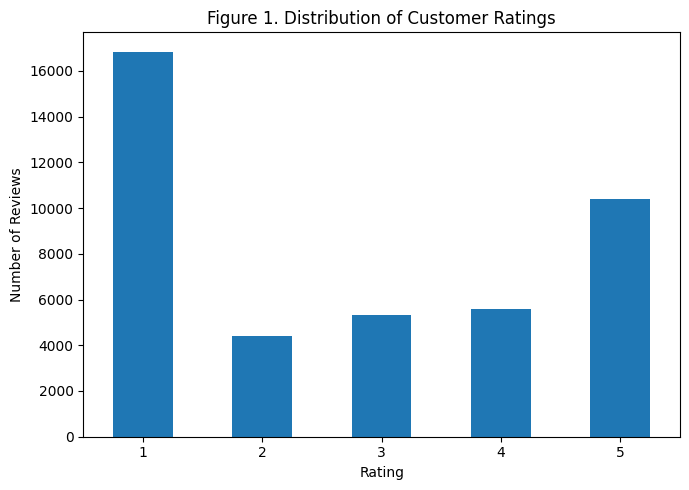

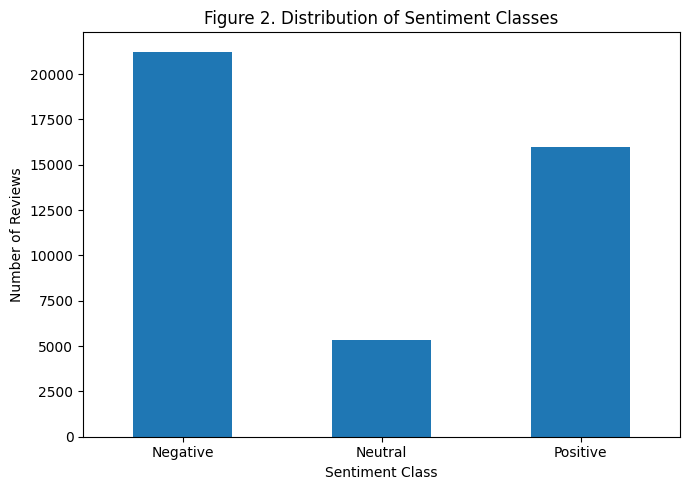

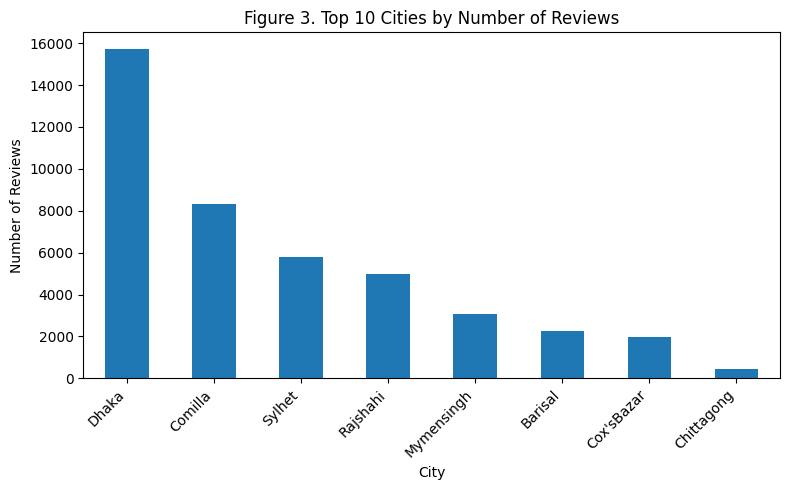

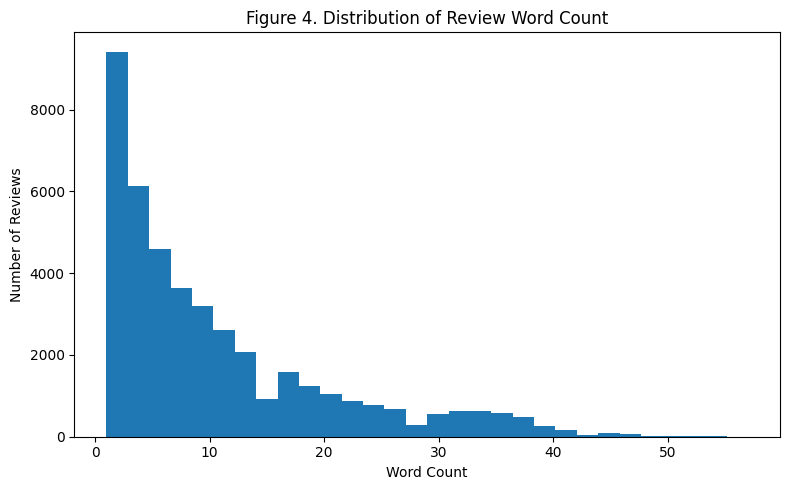

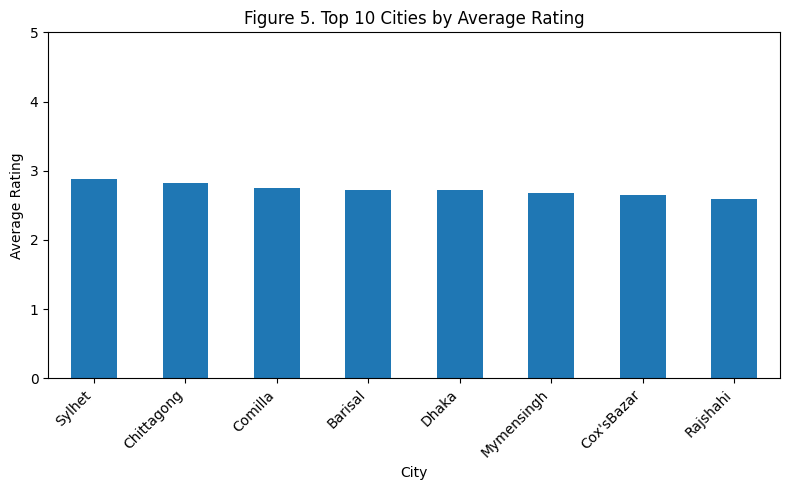

In [18]:
# I create clear EDA figures for the report

plt.figure(figsize=(7, 5))
df_clean["ratings_int"].value_counts().sort_index().plot(kind="bar")
plt.title("Figure 1. Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
df_clean["sentiment"].value_counts().reindex(["Negative", "Neutral", "Positive"]).plot(kind="bar")
plt.title("Figure 2. Distribution of Sentiment Classes")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
df_clean["city"].value_counts().head(10).plot(kind="bar")
plt.title("Figure 3. Top 10 Cities by Number of Reviews")
plt.xlabel("City")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
df_clean["review_word_count"].clip(upper=80).plot(kind="hist", bins=30)
plt.title("Figure 4. Distribution of Review Word Count")
plt.xlabel("Word Count")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

city_rating = (
    df_clean.groupby("city")["ratings_int"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
city_rating.plot(kind="bar")
plt.title("Figure 5. Top 10 Cities by Average Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

In [4]:
# I clean the review text for NLP modelling

import string

def clean_review_text(text):
    text = str(text).lower()
    
    # I remove URLs, mentions, numbers and punctuation because they add noise here
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # I remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df_clean["clean_text"] = df_clean["final_review_text"].apply(clean_review_text)

# I remove very short empty texts after cleaning
df_model = df_clean[df_clean["clean_text"].str.len() > 2].copy()

print("Shape before text cleaning:", df_clean.shape)
print("Shape after text cleaning:", df_model.shape)

print("\nSample before and after cleaning:")
display(
    df_model[["final_review_text", "clean_text", "ratings_int", "sentiment", "satisfaction_binary"]]
    .head(10)
)

print("\nShortest cleaned reviews:")
display(
    df_model[["clean_text", "ratings_int", "sentiment"]]
    .sort_values("clean_text")
    .head(10)
)

print("\nSentiment distribution after text cleaning:")
print(df_model["sentiment"].value_counts())

print("\nBinary satisfaction distribution after text cleaning:")
print(df_model["satisfaction_binary"].value_counts())

Shape before text cleaning: (42568, 16)
Shape after text cleaning: (42386, 16)

Sample before and after cleaning:


,final_review_text,clean_text,ratings_int,sentiment,satisfaction_binary
0,the amount of food very very less,the amount of food very very less,1,Negative,0
1,food packaging good ordered fried rice set me...,food packaging good ordered fried rice set mea...,4,Positive,1
2,the rice was horrible idk why barcode does it...,the rice was horrible idk why barcode does it ...,2,Negative,0
3,i ordered something and received something else,i ordered something and received something else,1,Negative,0
4,it was ok half the pizza slide off the bread ...,it was ok half the pizza slide off the bread b...,3,Neutral,0
5,assalamu llikum we are very sorry to inform y...,assalamu llikum we are very sorry to inform yo...,1,Negative,0
6,the delivery man asked for tips,the delivery man asked for tips,4,Positive,1
7,it was really bad no taste no nothing expected...,it was really bad no taste no nothing expected...,2,Negative,0
8,no honey in honey chicken cashewnut salad st...,no honey in honey chicken cashewnut salad stra...,2,Negative,0
9,great,great,5,Positive,1



Shortest cleaned reviews:


,clean_text,ratings_int,sentiment
8112,a bad biryani has no name cooked with plain ri...,1,Negative
13980,a bad biryani this was one of the worst biryan...,1,Negative
26838,a bad biryani with rotten cucumber ripe lemon,1,Negative
5020,a bad burial is done by mixing burgers and tis...,1,Negative
26795,a bad meal there was no mutton in the mutton t...,1,Negative
24884,a bad restaurant instead of rs special pech pa...,1,Negative
1325,a below average shawarma wrap at this price range,3,Neutral
13464,a big bone nothing to say about meat i am buyi...,1,Negative
41257,a binchod in this hala this bokachoda offers t...,1,Negative
11664,a biryani is not done just by placing the bone...,1,Negative



Sentiment distribution after text cleaning:
sentiment
Negative    21190
Positive    15886
Neutral      5310
Name: count, dtype: int64

Binary satisfaction distribution after text cleaning:
satisfaction_binary
0    26500
1    15886
Name: count, dtype: int64


In [5]:
# I prepare the text features and split the data for modelling

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_text = df_model["clean_text"]
y_binary = df_model["satisfaction_binary"]
y_multi = df_model["sentiment"]

# I use stratification because the classes are not evenly distributed
X_train_text, X_test_text, y_train_binary, y_test_binary = train_test_split(
    X_text,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)

# I keep the multi-class labels aligned with the same split for later analysis
_, _, y_train_multi, y_test_multi = train_test_split(
    X_text,
    y_multi,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)

# TF-IDF converts review text into numerical features for machine learning
tfidf = TfidfVectorizer(
    max_features=7000,
    min_df=3,
    max_df=0.90,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("Training text records:", X_train_text.shape[0])
print("Testing text records:", X_test_text.shape[0])

print("\nTF-IDF training matrix shape:", X_train_tfidf.shape)
print("TF-IDF testing matrix shape:", X_test_tfidf.shape)

print("\nBinary training class distribution:")
print(y_train_binary.value_counts())

print("\nBinary testing class distribution:")
print(y_test_binary.value_counts())

print("\nSample TF-IDF features:")
print(tfidf.get_feature_names_out()[:50])

Training text records: 33908
Testing text records: 8478

TF-IDF training matrix shape: (33908, 7000)
TF-IDF testing matrix shape: (8478, 7000)

Binary training class distribution:
satisfaction_binary
0    21199
1    12709
Name: count, dtype: int64

Binary testing class distribution:
satisfaction_binary
0    5301
1    3177
Name: count, dtype: int64

Sample TF-IDF features:
['abar' 'abesme' 'able' 'able eat' 'abominable' 'abr' 'absent' 'absolute'
 'absolutely' 'absolutely bad' 'absolutely cold' 'absolutely delicious'
 'absolutely disgusting' 'absolutely good' 'absolutely great'
 'absolutely horrible' 'absolutely loved' 'absolutely rubbish' 'accept'
 'acceptable' 'accompanied' 'according' 'according menu' 'according money'
 'according order' 'according price' 'according quantity' 'accordingly'
 'account' 'accurate' 'ace' 'achar' 'achari' 'achari rice' 'ache' 'act'
 'action' 'actu' 'actual' 'actual price' 'actually' 'add' 'add extra'
 'add little' 'add ons' 'add salad' 'added' 'added extra

In [6]:
# I train several baseline models and compare them fairly

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

baseline_results = []

for model_name, model in models.items():
    print(f"\nTraining: {model_name}")
    
    model.fit(X_train_tfidf, y_train_binary)
    y_pred = model.predict(X_test_tfidf)
    
    baseline_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_binary, y_pred),
        "Precision": precision_score(y_test_binary, y_pred),
        "Recall": recall_score(y_test_binary, y_pred),
        "F1-score": f1_score(y_test_binary, y_pred)
    })
    
    print(f"\nClassification report for {model_name}:")
    print(classification_report(y_test_binary, y_pred, target_names=["Not Satisfied", "Satisfied"]))
    
baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df = baseline_results_df.sort_values("F1-score", ascending=False)

print("\nBaseline model comparison:")
display(baseline_results_df)


Training: Naive Bayes

Classification report for Naive Bayes:
               precision    recall  f1-score   support

Not Satisfied       0.85      0.89      0.87      5301
    Satisfied       0.80      0.74      0.77      3177

     accuracy                           0.83      8478
    macro avg       0.83      0.81      0.82      8478
 weighted avg       0.83      0.83      0.83      8478


Training: Logistic Regression

Classification report for Logistic Regression:
               precision    recall  f1-score   support

Not Satisfied       0.88      0.85      0.87      5301
    Satisfied       0.76      0.81      0.78      3177

     accuracy                           0.83      8478
    macro avg       0.82      0.83      0.83      8478
 weighted avg       0.84      0.83      0.84      8478


Training: Linear SVM

Classification report for Linear SVM:
               precision    recall  f1-score   support

Not Satisfied       0.88      0.83      0.86      5301
    Satisfied       

,Model,Accuracy,Precision,Recall,F1-score
1,Logistic Regression,0.834277,0.764162,0.806736,0.784872
2,Linear SVM,0.824369,0.745206,0.807365,0.775042
3,Random Forest,0.826728,0.756919,0.791942,0.774035
0,Naive Bayes,0.833569,0.802397,0.737488,0.768575


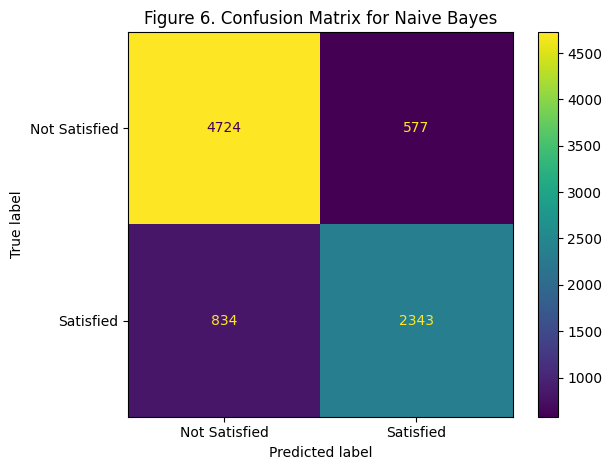

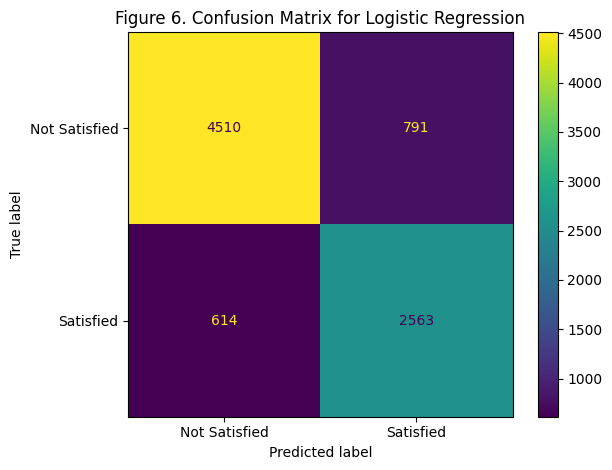

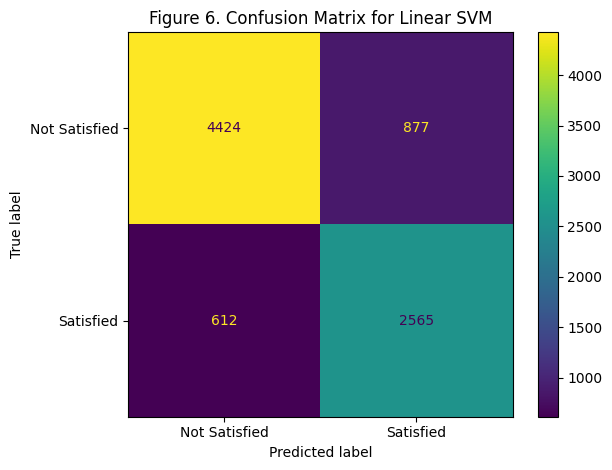

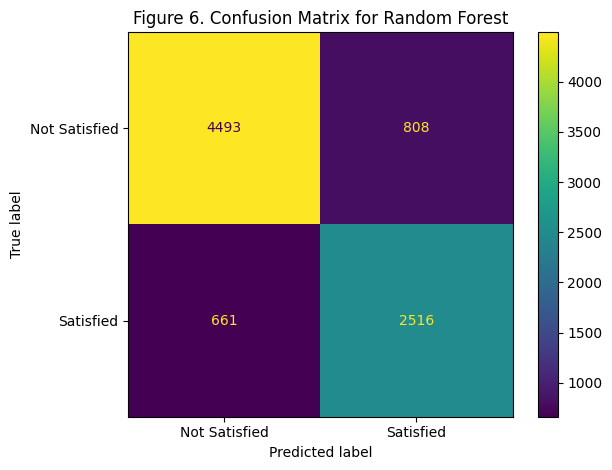

<Figure size 900x500 with 0 Axes>

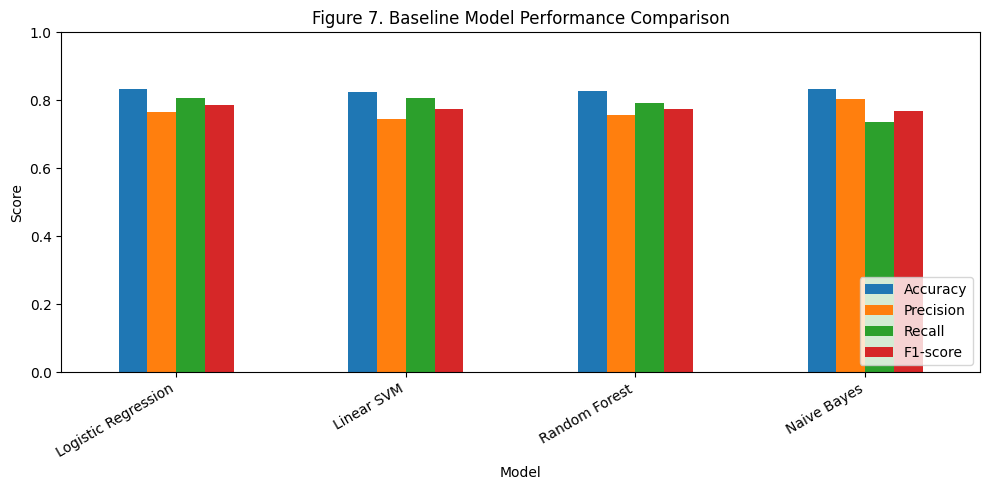

In [7]:
# I visualise model performance for the report

from sklearn.metrics import ConfusionMatrixDisplay

trained_models = {}
model_predictions = {}

for model_name, model in models.items():
    model.fit(X_train_tfidf, y_train_binary)
    y_pred = model.predict(X_test_tfidf)
    trained_models[model_name] = model
    model_predictions[model_name] = y_pred

# I show a confusion matrix for each model
for model_name, y_pred in model_predictions.items():
    cm = confusion_matrix(y_test_binary, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Satisfied", "Satisfied"]
    )
    
    disp.plot(values_format="d")
    plt.title(f"Figure 6. Confusion Matrix for {model_name}")
    plt.tight_layout()
    plt.show()

# I plot the baseline model comparison
baseline_plot_df = baseline_results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]]

plt.figure(figsize=(9, 5))
baseline_plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Figure 7. Baseline Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Training for ROC-AUC: Naive Bayes
Training for ROC-AUC: Logistic Regression
Training for ROC-AUC: Random Forest


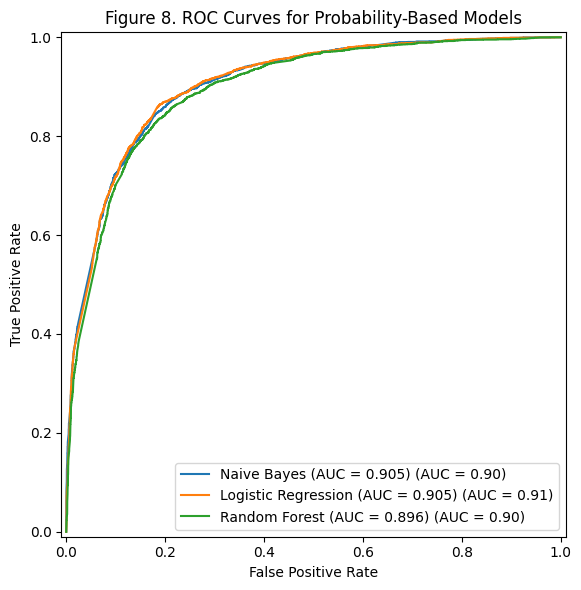


ROC-AUC comparison:


,Model,ROC-AUC
1,Logistic Regression,0.905279
0,Naive Bayes,0.904816
2,Random Forest,0.895760


In [8]:
# I calculate ROC-AUC for models that provide probability scores

from sklearn.metrics import roc_auc_score, RocCurveDisplay

probability_models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

roc_results = []

plt.figure(figsize=(8, 6))

for model_name, model in probability_models.items():
    print(f"Training for ROC-AUC: {model_name}")
    
    model.fit(X_train_tfidf, y_train_binary)
    y_prob = model.predict_proba(X_test_tfidf)[:, 1]
    auc_score = roc_auc_score(y_test_binary, y_prob)
    
    roc_results.append({
        "Model": model_name,
        "ROC-AUC": auc_score
    })
    
    RocCurveDisplay.from_predictions(
        y_test_binary,
        y_prob,
        name=f"{model_name} (AUC = {auc_score:.3f})",
        ax=plt.gca()
    )

plt.title("Figure 8. ROC Curves for Probability-Based Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

roc_results_df = pd.DataFrame(roc_results).sort_values("ROC-AUC", ascending=False)

print("\nROC-AUC comparison:")
display(roc_results_df)

In [10]:
# I tune Logistic Regression and compare it with the baseline result

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        min_df=3,
        max_df=0.90,
        ngram_range=(1, 2)
    )),
    ("model", LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "tfidf__max_features": [7000, 10000, 12000],
    "model__C": [0.5, 1.0, 2.0],
    "model__solver": ["liblinear"]
}

grid_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train_text, y_train_binary)

print("Best parameters:")
print(grid_lr.best_params_)

print("\nBest cross-validation F1-score:")
print(round(grid_lr.best_score_, 4))

best_lr_model = grid_lr.best_estimator_

# I evaluate the tuned model on the untouched test set
y_pred_tuned_lr = best_lr_model.predict(X_test_text)
y_prob_tuned_lr = best_lr_model.predict_proba(X_test_text)[:, 1]

tuned_lr_results = {
    "Model": "Tuned Logistic Regression",
    "Accuracy": accuracy_score(y_test_binary, y_pred_tuned_lr),
    "Precision": precision_score(y_test_binary, y_pred_tuned_lr),
    "Recall": recall_score(y_test_binary, y_pred_tuned_lr),
    "F1-score": f1_score(y_test_binary, y_pred_tuned_lr),
    "ROC-AUC": roc_auc_score(y_test_binary, y_prob_tuned_lr)
}

print("\nTuned Logistic Regression classification report:")
print(classification_report(y_test_binary, y_pred_tuned_lr, target_names=["Not Satisfied", "Satisfied"]))

print("\nTuned Logistic Regression summary:")
tuned_lr_df = pd.DataFrame([tuned_lr_results])
display(tuned_lr_df)

# I compare baseline Logistic Regression with the tuned Logistic Regression
baseline_lr_row = baseline_results_df[baseline_results_df["Model"] == "Logistic Regression"].copy()
baseline_lr_row["ROC-AUC"] = roc_results_df.loc[
    roc_results_df["Model"] == "Logistic Regression", "ROC-AUC"
].values[0]

final_lr_comparison = pd.concat(
    [baseline_lr_row, tuned_lr_df],
    ignore_index=True
)

print("\nBaseline vs tuned Logistic Regression:")
display(final_lr_comparison)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters:
{'model__C': 1.0, 'model__solver': 'liblinear', 'tfidf__max_features': 10000}

Best cross-validation F1-score:
0.7804

Tuned Logistic Regression classification report:
               precision    recall  f1-score   support

Not Satisfied       0.88      0.85      0.87      5301
    Satisfied       0.76      0.81      0.79      3177

     accuracy                           0.83      8478
    macro avg       0.82      0.83      0.83      8478
 weighted avg       0.84      0.83      0.84      8478


Tuned Logistic Regression summary:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Tuned Logistic Regression,0.834631,0.764216,0.807995,0.785496,0.905198



Baseline vs tuned Logistic Regression:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.834277,0.764162,0.806736,0.784872,0.905279
1,Tuned Logistic Regression,0.834631,0.764216,0.807995,0.785496,0.905198


Top words associated with satisfied reviews:


,feature,coefficient
605,best,7.583210
2467,excellent,5.672874
153,amazing,5.296686
3471,great,4.893810
279,awesome,4.707012
4977,loved,4.415318
6679,perfect,4.293581
1901,delicious,4.078833
4966,love,3.983464
9990,yummy,3.653408



Top words associated with not satisfied reviews:


,feature,coefficient
9903,worst,-6.428657
6979,poor,-4.578605
8044,rotten,-4.050374
2171,disgusting,-4.045496
2147,disappointed,-3.806287
2158,disappointing,-3.643829
3742,horrible,-3.458880
8860,stale,-3.417526
339,bad food,-3.219040
2063,didn,-3.191026


<Figure size 800x600 with 0 Axes>

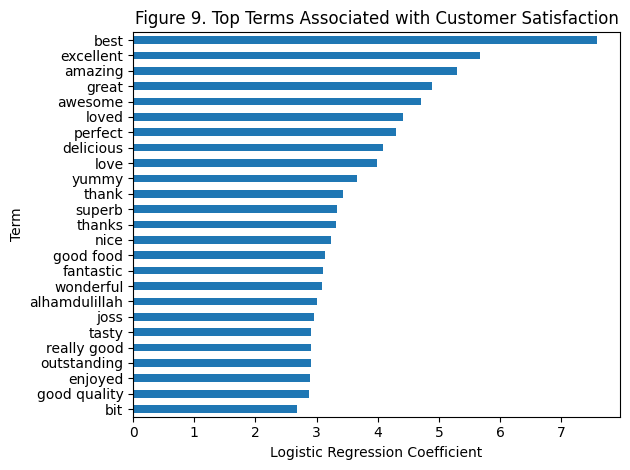

<Figure size 800x600 with 0 Axes>

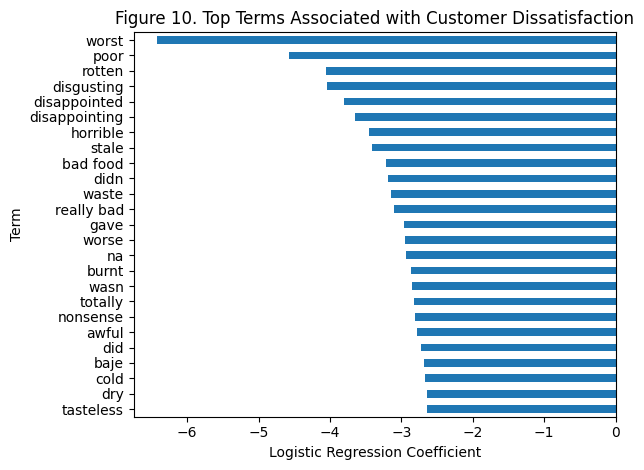

In [11]:
# I identify the most influential words for satisfaction and dissatisfaction

best_tfidf = best_lr_model.named_steps["tfidf"]
best_classifier = best_lr_model.named_steps["model"]

feature_names = np.array(best_tfidf.get_feature_names_out())
coefficients = best_classifier.coef_[0]

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

top_positive_words = feature_importance_df.sort_values("coefficient", ascending=False).head(25)
top_negative_words = feature_importance_df.sort_values("coefficient", ascending=True).head(25)

print("Top words associated with satisfied reviews:")
display(top_positive_words)

print("\nTop words associated with not satisfied reviews:")
display(top_negative_words)

plt.figure(figsize=(8, 6))
top_positive_words.sort_values("coefficient").plot(
    x="feature",
    y="coefficient",
    kind="barh",
    legend=False
)
plt.title("Figure 9. Top Terms Associated with Customer Satisfaction")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
top_negative_words.sort_values("coefficient", ascending=False).plot(
    x="feature",
    y="coefficient",
    kind="barh",
    legend=False
)
plt.title("Figure 10. Top Terms Associated with Customer Dissatisfaction")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

In [12]:
# I train multi-class sentiment models for Negative, Neutral and Positive reviews

from sklearn.metrics import classification_report

X_train_multi_text, X_test_multi_text, y_train_multi, y_test_multi = train_test_split(
    df_model["clean_text"],
    df_model["sentiment"],
    test_size=0.20,
    random_state=42,
    stratify=df_model["sentiment"]
)

multi_tfidf = TfidfVectorizer(
    max_features=10000,
    min_df=3,
    max_df=0.90,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_multi_tfidf = multi_tfidf.fit_transform(X_train_multi_text)
X_test_multi_tfidf = multi_tfidf.transform(X_test_multi_text)

multi_models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        random_state=42
    ),
    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42
    )
}

multi_results = []

for model_name, model in multi_models.items():
    print(f"\nTraining multi-class model: {model_name}")
    
    model.fit(X_train_multi_tfidf, y_train_multi)
    y_pred_multi = model.predict(X_test_multi_tfidf)
    
    report = classification_report(
        y_test_multi,
        y_pred_multi,
        output_dict=True
    )
    
    multi_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_multi, y_pred_multi),
        "Macro Precision": report["macro avg"]["precision"],
        "Macro Recall": report["macro avg"]["recall"],
        "Macro F1-score": report["macro avg"]["f1-score"],
        "Weighted F1-score": report["weighted avg"]["f1-score"]
    })
    
    print(f"\nClassification report for {model_name}:")
    print(classification_report(y_test_multi, y_pred_multi))

multi_results_df = pd.DataFrame(multi_results).sort_values("Macro F1-score", ascending=False)

print("\nMulti-class model comparison:")
display(multi_results_df)


Training multi-class model: Naive Bayes

Classification report for Naive Bayes:
              precision    recall  f1-score   support

    Negative       0.75      0.90      0.82      4238
     Neutral       0.40      0.01      0.03      1062
    Positive       0.76      0.81      0.78      3178

    accuracy                           0.75      8478
   macro avg       0.64      0.57      0.54      8478
weighted avg       0.71      0.75      0.71      8478


Training multi-class model: Logistic Regression

Classification report for Logistic Regression:
              precision    recall  f1-score   support

    Negative       0.82      0.74      0.78      4238
     Neutral       0.28      0.46      0.35      1062
    Positive       0.79      0.74      0.76      3178

    accuracy                           0.70      8478
   macro avg       0.63      0.65      0.63      8478
weighted avg       0.75      0.70      0.72      8478


Training multi-class model: Linear SVM

Classification repo

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted F1-score
1,Logistic Regression,0.704883,0.633898,0.645163,0.631830,0.721019
2,Linear SVM,0.716089,0.613406,0.614643,0.613941,0.717882
0,Naive Bayes,0.753362,0.637341,0.572970,0.542360,0.705765


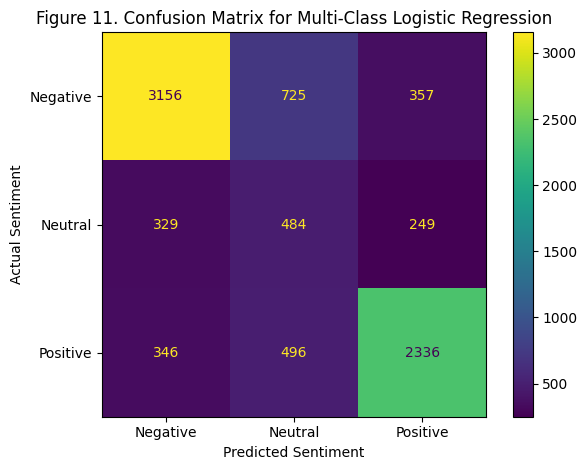

<Figure size 1000x500 with 0 Axes>

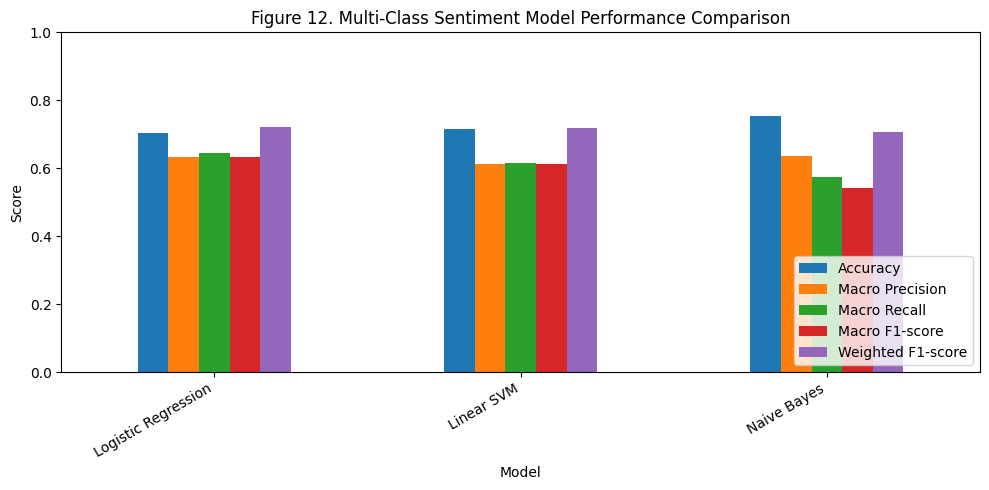

Best multi-class model confusion matrix:


,Negative,Neutral,Positive
Negative,3156,725,357
Neutral,329,484,249
Positive,346,496,2336


In [13]:
# I visualise the best multi-class model results

best_multi_model = LogisticRegression(
    max_iter=1500,
    class_weight="balanced",
    random_state=42
)

best_multi_model.fit(X_train_multi_tfidf, y_train_multi)
y_pred_best_multi = best_multi_model.predict(X_test_multi_tfidf)

labels_order = ["Negative", "Neutral", "Positive"]

cm_multi = confusion_matrix(
    y_test_multi,
    y_pred_best_multi,
    labels=labels_order
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_multi,
    display_labels=labels_order
)

disp.plot(values_format="d")
plt.title("Figure 11. Confusion Matrix for Multi-Class Logistic Regression")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

multi_plot_df = multi_results_df.set_index("Model")[[
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1-score",
    "Weighted F1-score"
]]

plt.figure(figsize=(10, 5))
multi_plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Figure 12. Multi-Class Sentiment Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Best multi-class model confusion matrix:")
display(pd.DataFrame(cm_multi, index=labels_order, columns=labels_order))

Total aspect mentions: 26994

Aspect frequency:


aspect
Food Quality          14707
Service Experience     4533
Price and Value        3287
Delivery               3211
Packaging              1256
Name: count, dtype: int64


Average rating by aspect:


,count,mean
aspect,,
Food Quality,14707,2.595703
Service Experience,4533,1.923891
Price and Value,3287,2.282629
Delivery,3211,2.310807
Packaging,1256,2.455414



Sentiment distribution by aspect:


sentiment,Negative,Neutral,Positive
aspect,,,
Delivery,61.41,12.58,26.00
Food Quality,53.99,11.79,34.22
Packaging,55.81,14.57,29.62
Price and Value,61.79,12.14,26.07
Service Experience,73.97,7.21,18.82


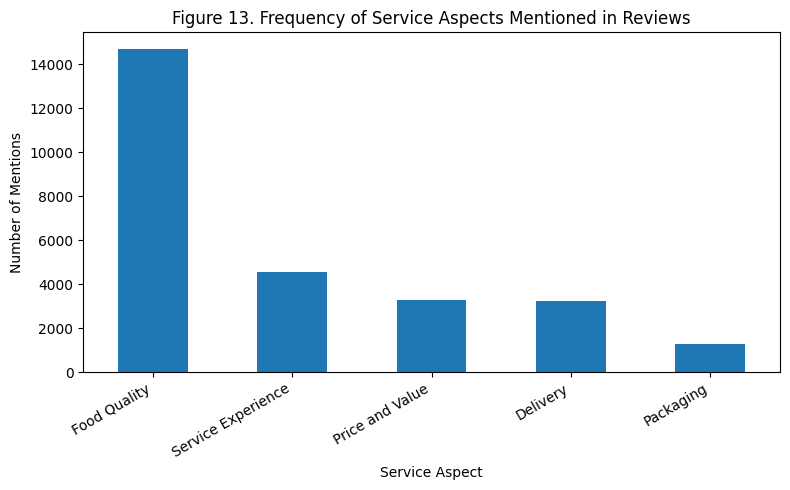

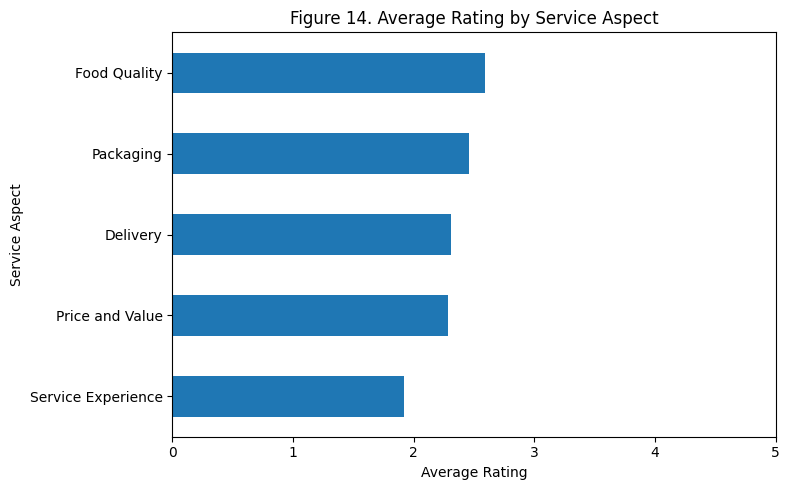

In [14]:
# I analyse important service themes using keyword groups

aspect_keywords = {
    "Food Quality": [
        "food", "taste", "tasty", "delicious", "stale", "rotten", "cold",
        "fresh", "quality", "burnt", "dry", "spicy", "salt", "sweet"
    ],
    "Delivery": [
        "delivery", "late", "delay", "rider", "driver", "delivered",
        "time", "fast", "slow", "waiting", "wait"
    ],
    "Packaging": [
        "packaging", "package", "packed", "box", "parcel", "leak",
        "spill", "broken", "seal"
    ],
    "Price and Value": [
        "price", "expensive", "cheap", "cost", "value", "money",
        "waste", "worth", "overpriced"
    ],
    "Service Experience": [
        "service", "restaurant", "order", "wrong", "missing", "support",
        "refund", "cancel", "customer", "behavior", "rude"
    ]
}

def detect_aspects(text):
    found_aspects = []
    words = set(str(text).split())
    
    for aspect, keywords in aspect_keywords.items():
        if any(keyword in words for keyword in keywords):
            found_aspects.append(aspect)
            
    return found_aspects

df_model["detected_aspects"] = df_model["clean_text"].apply(detect_aspects)

aspect_rows = []

for _, row in df_model.iterrows():
    for aspect in row["detected_aspects"]:
        aspect_rows.append({
            "aspect": aspect,
            "ratings_int": row["ratings_int"],
            "sentiment": row["sentiment"],
            "satisfaction_binary": row["satisfaction_binary"]
        })

aspect_df = pd.DataFrame(aspect_rows)

print("Total aspect mentions:", len(aspect_df))

print("\nAspect frequency:")
aspect_frequency = aspect_df["aspect"].value_counts()
display(aspect_frequency)

print("\nAverage rating by aspect:")
aspect_rating_summary = (
    aspect_df.groupby("aspect")["ratings_int"]
    .agg(["count", "mean"])
    .sort_values("count", ascending=False)
)
display(aspect_rating_summary)

print("\nSentiment distribution by aspect:")
aspect_sentiment_table = pd.crosstab(
    aspect_df["aspect"],
    aspect_df["sentiment"],
    normalize="index"
) * 100

display(aspect_sentiment_table.round(2))

plt.figure(figsize=(8, 5))
aspect_frequency.plot(kind="bar")
plt.title("Figure 13. Frequency of Service Aspects Mentioned in Reviews")
plt.xlabel("Service Aspect")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
aspect_rating_summary["mean"].sort_values().plot(kind="barh")
plt.title("Figure 14. Average Rating by Service Aspect")
plt.xlabel("Average Rating")
plt.ylabel("Service Aspect")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

City-level satisfaction summary:


,review_count,average_rating,satisfied_rate,satisfied_rate_percent
city,,,,
Dhaka,15675,2.718150,0.368804,36.880383
Comilla,8262,2.741225,0.388405,38.840474
Sylhet,5778,2.872620,0.415196,41.519557
Rajshahi,4946,2.582491,0.340679,34.067934
Mymensingh,3077,2.670783,0.368541,36.854079
Barisal,2235,2.719911,0.368680,36.868009
Cox'sBazar,1986,2.651057,0.348439,34.843907
Chittagong,427,2.826698,0.379391,37.939110



Top cities by average rating:


,review_count,average_rating,satisfied_rate,satisfied_rate_percent
city,,,,
Sylhet,5778,2.872620,0.415196,41.519557
Chittagong,427,2.826698,0.379391,37.939110
Comilla,8262,2.741225,0.388405,38.840474
Barisal,2235,2.719911,0.368680,36.868009
Dhaka,15675,2.718150,0.368804,36.880383
Mymensingh,3077,2.670783,0.368541,36.854079
Cox'sBazar,1986,2.651057,0.348439,34.843907
Rajshahi,4946,2.582491,0.340679,34.067934



Lowest cities by average rating:


,review_count,average_rating,satisfied_rate,satisfied_rate_percent
city,,,,
Rajshahi,4946,2.582491,0.340679,34.067934
Cox'sBazar,1986,2.651057,0.348439,34.843907
Mymensingh,3077,2.670783,0.368541,36.854079
Dhaka,15675,2.718150,0.368804,36.880383
Barisal,2235,2.719911,0.368680,36.868009
Comilla,8262,2.741225,0.388405,38.840474
Chittagong,427,2.826698,0.379391,37.939110
Sylhet,5778,2.872620,0.415196,41.519557


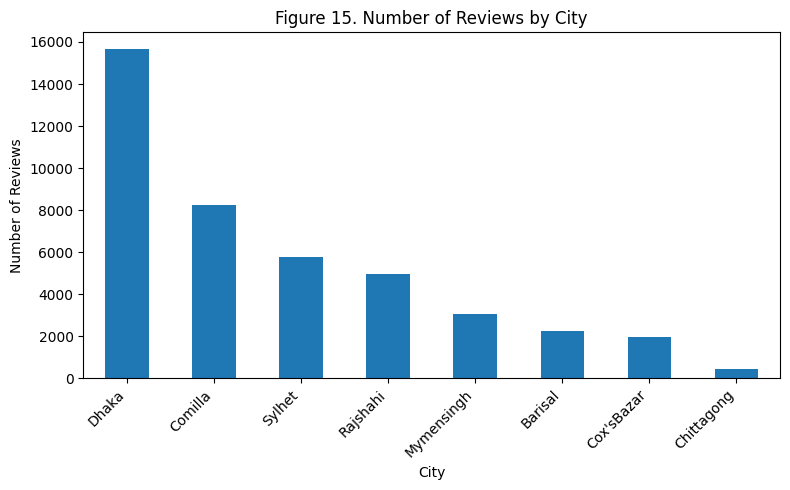

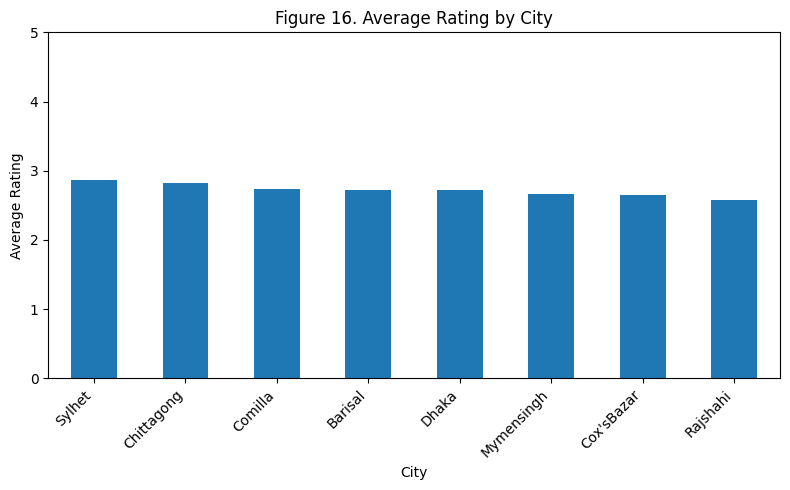

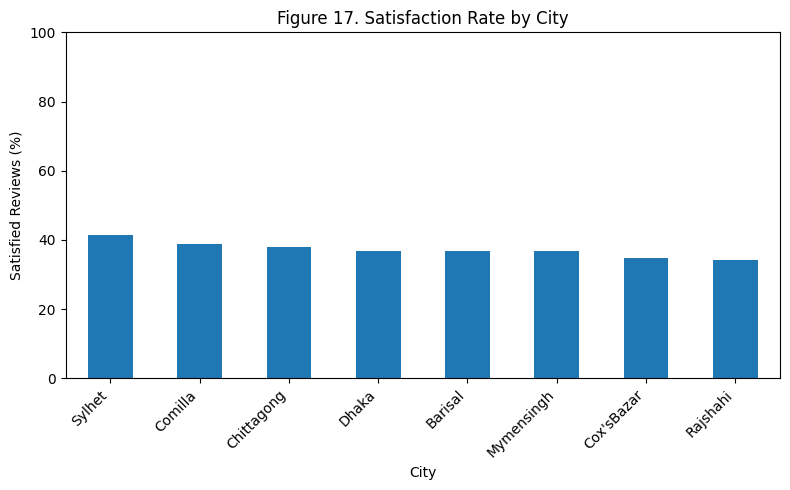

In [15]:
# I analyse customer satisfaction across cities

city_summary = (
    df_model.groupby("city")
    .agg(
        review_count=("ratings_int", "count"),
        average_rating=("ratings_int", "mean"),
        satisfied_rate=("satisfaction_binary", "mean")
    )
    .sort_values("review_count", ascending=False)
)

city_summary["satisfied_rate_percent"] = city_summary["satisfied_rate"] * 100

print("City-level satisfaction summary:")
display(city_summary)

print("\nTop cities by average rating:")
display(city_summary.sort_values("average_rating", ascending=False).head(10))

print("\nLowest cities by average rating:")
display(city_summary.sort_values("average_rating", ascending=True).head(10))

plt.figure(figsize=(8, 5))
city_summary["review_count"].head(10).plot(kind="bar")
plt.title("Figure 15. Number of Reviews by City")
plt.xlabel("City")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
city_summary["average_rating"].sort_values(ascending=False).plot(kind="bar")
plt.title("Figure 16. Average Rating by City")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
city_summary["satisfied_rate_percent"].sort_values(ascending=False).plot(kind="bar")
plt.title("Figure 17. Satisfaction Rate by City")
plt.xlabel("City")
plt.ylabel("Satisfied Reviews (%)")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Number of restaurants with at least 100 reviews: 136

Top 10 most reviewed restaurants:


,review_count,average_rating,satisfied_rate,satisfied_rate_percent
restaurant,,,,
Burger Xpress - Wari,646,3.125387,0.481424,48.142415
Kacchi Bhai - Dhanmondi,639,2.713615,0.361502,36.150235
Noor Kacchi House-7 Rasta,606,2.816832,0.415842,41.584158
Kacchi Bari - Dhanmondi,597,3.005025,0.462312,46.231156
Arabian Kitchen,554,2.680505,0.373646,37.364621
Suntan's Dine - Puran Dhaka,539,2.682746,0.369202,36.920223
Lalbag Biryani House - Dhanmondi,538,2.767658,0.388476,38.847584
Panshi Restaurant,520,2.700000,0.363462,36.346154
Aziz Canteen,509,2.644401,0.351670,35.166994



Top 10 restaurants by average rating, minimum 100 reviews:


,review_count,average_rating,satisfied_rate,satisfied_rate_percent
restaurant,,,,
Tabaq Coffee - Dhanmondi,107,3.467290,0.560748,56.074766
Khulna Grand Darbar Restaurant & Party Center,112,3.419643,0.544643,54.464286
Master Chef Chinese Restaurant,159,3.415094,0.591195,59.119497
Rany's Mom Kitchen,150,3.400000,0.560000,56.000000
Hungry Heroes,145,3.365517,0.531034,53.103448
Haji Kacchi Ghor - Barishal,335,3.364179,0.549254,54.925373
Takeout - Banani,203,3.349754,0.517241,51.724138
Chinese Palace,369,3.346883,0.539295,53.929539
Burger Side,123,3.308943,0.552846,55.284553



Lowest 10 restaurants by average rating, minimum 100 reviews:


,review_count,average_rating,satisfied_rate,satisfied_rate_percent
restaurant,,,,
Nawab's Kitchen - Rajshahi,393,1.730280,0.142494,14.249364
Bismillah Hotel & Restaurant - Dhanmondi,470,1.748936,0.134043,13.404255
Nirob Hotel,108,1.750000,0.120370,12.037037
Rajib Biryani House,201,1.761194,0.139303,13.930348
Golden Spoon Khulna,451,1.773836,0.152993,15.299335
Grameen Restora & Biryani House,135,1.874074,0.140741,14.074074
Hello Dhanmondi Cafe,249,1.887550,0.172691,17.269076
Shawarama House - Barisal,126,1.920635,0.119048,11.904762
Shatkhira Vagyakul Ghosh Dairy,115,1.982609,0.200000,20.000000



Top 10 restaurants by satisfaction rate, minimum 100 reviews:


,review_count,average_rating,satisfied_rate,satisfied_rate_percent
restaurant,,,,
Master Chef Chinese Restaurant,159,3.415094,0.591195,59.119497
Tabaq Coffee - Dhanmondi,107,3.467290,0.560748,56.074766
Rany's Mom Kitchen,150,3.400000,0.560000,56.000000
Burger Side,123,3.308943,0.552846,55.284553
Haji Kacchi Ghor - Barishal,335,3.364179,0.549254,54.925373
Khulna Grand Darbar Restaurant & Party Center,112,3.419643,0.544643,54.464286
Royal Kitchen,331,3.296073,0.540785,54.078550
Zafran Restaurant - Sylhet,346,3.283237,0.540462,54.046243
Chinese Palace,369,3.346883,0.539295,53.929539



Lowest 10 restaurants by satisfaction rate, minimum 100 reviews:


,review_count,average_rating,satisfied_rate,satisfied_rate_percent
restaurant,,,,
Shawarama House - Barisal,126,1.920635,0.119048,11.904762
Nirob Hotel,108,1.750000,0.120370,12.037037
Bismillah Hotel & Restaurant - Dhanmondi,470,1.748936,0.134043,13.404255
Rajib Biryani House,201,1.761194,0.139303,13.930348
Grameen Restora & Biryani House,135,1.874074,0.140741,14.074074
Nawab's Kitchen - Rajshahi,393,1.730280,0.142494,14.249364
Golden Spoon Khulna,451,1.773836,0.152993,15.299335
Hello Dhanmondi Cafe,249,1.887550,0.172691,17.269076
Shatkhira Vagyakul Ghosh Dairy,115,1.982609,0.200000,20.000000


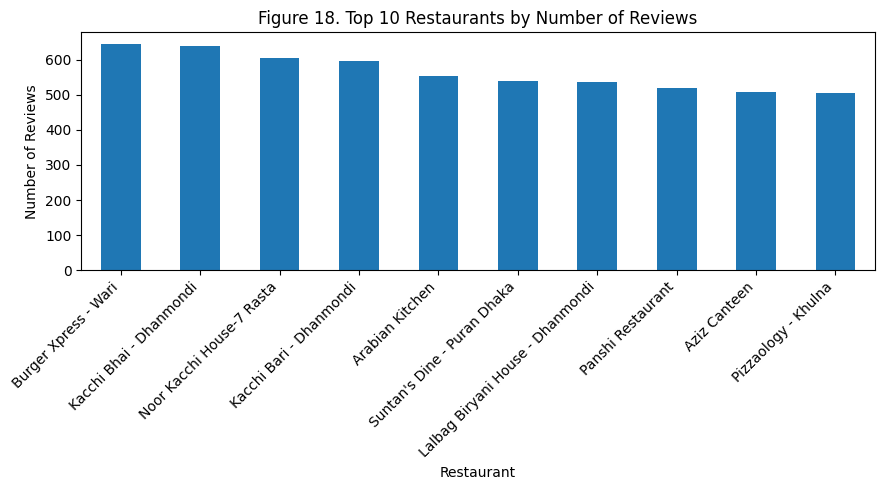

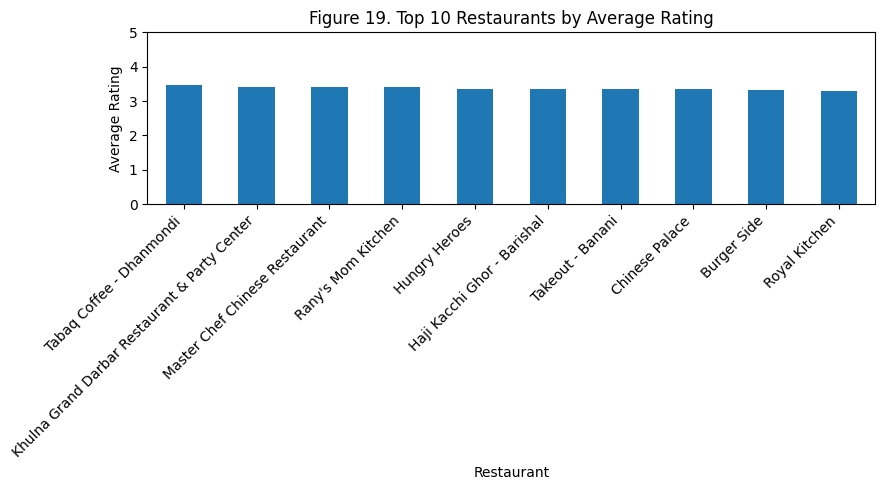

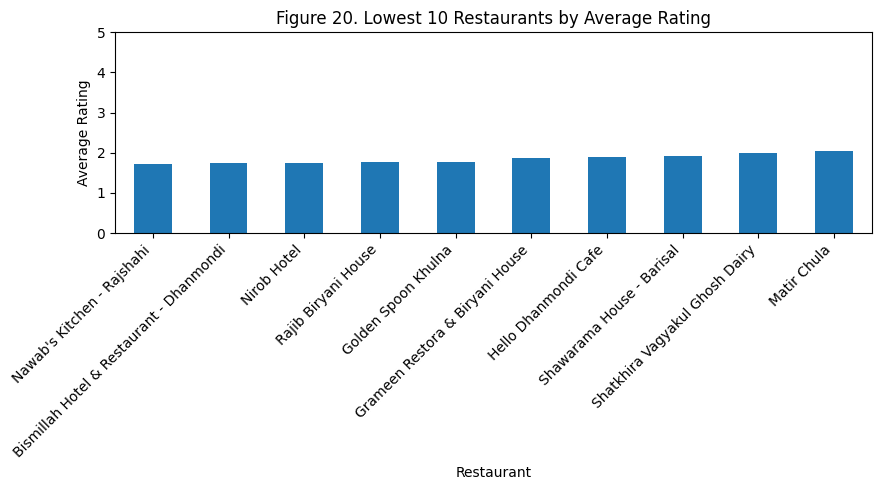

In [16]:
# I analyse restaurant-level performance using review count, rating and satisfaction rate

restaurant_summary = (
    df_model.groupby("restaurant")
    .agg(
        review_count=("ratings_int", "count"),
        average_rating=("ratings_int", "mean"),
        satisfied_rate=("satisfaction_binary", "mean")
    )
)

restaurant_summary["satisfied_rate_percent"] = restaurant_summary["satisfied_rate"] * 100

# I only compare restaurants with enough reviews to avoid weak conclusions
restaurant_reliable = restaurant_summary[restaurant_summary["review_count"] >= 100].copy()

restaurant_reliable = restaurant_reliable.sort_values("review_count", ascending=False)

print("Number of restaurants with at least 100 reviews:", restaurant_reliable.shape[0])

print("\nTop 10 most reviewed restaurants:")
display(restaurant_reliable.head(10))

print("\nTop 10 restaurants by average rating, minimum 100 reviews:")
display(
    restaurant_reliable.sort_values("average_rating", ascending=False).head(10)
)

print("\nLowest 10 restaurants by average rating, minimum 100 reviews:")
display(
    restaurant_reliable.sort_values("average_rating", ascending=True).head(10)
)

print("\nTop 10 restaurants by satisfaction rate, minimum 100 reviews:")
display(
    restaurant_reliable.sort_values("satisfied_rate_percent", ascending=False).head(10)
)

print("\nLowest 10 restaurants by satisfaction rate, minimum 100 reviews:")
display(
    restaurant_reliable.sort_values("satisfied_rate_percent", ascending=True).head(10)
)

plt.figure(figsize=(9, 5))
restaurant_reliable.sort_values("review_count", ascending=False).head(10)["review_count"].plot(kind="bar")
plt.title("Figure 18. Top 10 Restaurants by Number of Reviews")
plt.xlabel("Restaurant")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
restaurant_reliable.sort_values("average_rating", ascending=False).head(10)["average_rating"].plot(kind="bar")
plt.title("Figure 19. Top 10 Restaurants by Average Rating")
plt.xlabel("Restaurant")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
restaurant_reliable.sort_values("average_rating", ascending=True).head(10)["average_rating"].plot(kind="bar")
plt.title("Figure 20. Lowest 10 Restaurants by Average Rating")
plt.xlabel("Restaurant")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()